<a href="https://colab.research.google.com/github/Himanshu-Meshram/Projects/blob/Unified-Mentor-Projects/TRAIL-Laptop_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("mohidabdulrehman/laptop-price-dataset")

# print("Path to dataset files:", path)


In [ ]:
## Importing DATA SET
data = pd.read_csv('/content/laptop_data.csv')
data.head()
data.dtypes
data.columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

In [ ]:
## Handling Missing Values.
data.isnull().sum()

## if null value occurs.
## data=data.dropna()

data
data.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [ ]:
## Converting categorical columns to numerical using One-Hot Encoding
data1 = pd.get_dummies(data, columns=['Company','Cpu','Gpu','TypeName','ScreenResolution','Ram','Memory','OpSys','Weight','Weight'],
                        drop_first=True)
data1


,Unnamed: 0,Inches,Price,Company_Apple,Company_Asus,Company_Chuwi,Company_Dell,Company_Fujitsu,Company_Google,Company_HP,...,Weight_4.2kg,Weight_4.33kg,Weight_4.36kg,Weight_4.3kg,Weight_4.42kg,Weight_4.4kg,Weight_4.5kg,Weight_4.6kg,Weight_4.7kg,Weight_4kg
0,0,13.3,71378.6832,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,13.3,47895.5232,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2,15.6,30636.0000,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
3,3,15.4,135195.3360,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,4,13.3,96095.8080,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298,1298,14.0,33992.6400,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1299,1299,13.3,79866.7200,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1300,1300,14.0,12201.1200,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1301,1301,15.6,40705.9200,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
## M.L.
X = data1.drop('Price', axis=1)    # Features (independent variables)
Y = data1['Price']                 # Target variable (dependent variables)

In [ ]:
## demonstrate
X_train, X_test, Y_train, y_test = train_test_split(X, Y,
test_size=0.2, random_state=42)

In [ ]:
## introducing Linear Regression
model = LinearRegression()
model.fit(X_train, Y_train)


LinearRegression()

In [ ]:
## Making Predictions
y_pred = model.predict(X_test)

In [ ]:
##  MODEL
## Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

## calculate R-squared
r2 = r2_score(y_test, y_pred)
print(f"R-squared:{r2}")

Mean Squared Error: 323323590.3546495
R-squared:0.775762590570936


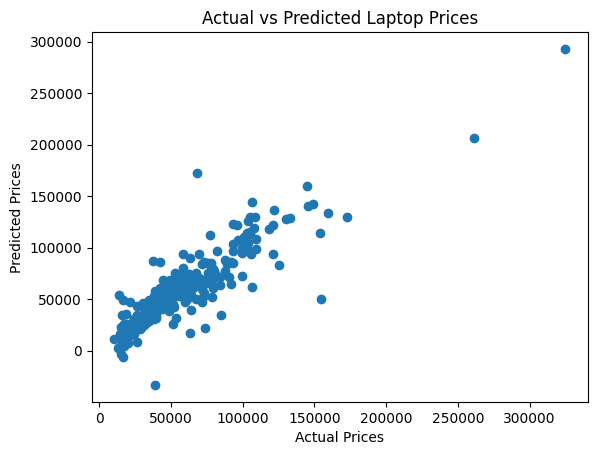

In [ ]:
## Visualization of the Model
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Laptop Prices")
plt.show()